# IntelliMaint

## Exploratory Data Analysis (EDA)

Dataset: AI4I 2020 Predictive Maintenance Dataset

### Objective

The objective of this notebook is to understand the dataset,
identify patterns, detect missing values,
analyze feature distributions,
and prepare the data for machine learning.

In [1]:
import sys
print(sys.executable)

c:\Users\goyal\OneDrive\Desktop\Intelliment\.venv\Scripts\python.exe


In [2]:
%pip install pandas numpy matplotlib seaborn

  Using cached pandas-3.0.5-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached matplotlib-3.11.1-cp313-cp313-win_amd64.whl.metadata (80 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached tzdata-2026.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp313-cp313-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp313-cp313-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached pandas-3.0.5-cp313-cp313-win_amd64.whl (9.8 MB)
   ---------------------------------------- 0.0/12.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.5 MB ? eta -:--:--
   ----------------


[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

%matplotlib inline

Matplotlib is building the font cache; this may take a moment.


## Load Dataset

In [4]:
df = pd.read_csv("../dataset/ai4i2020.csv")

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## Dataset Overview

In [5]:
df.shape

(10000, 14)

### Observation

The dataset contains 10000 rows and 14 columns.

In [6]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='str')

### Observation

The dataset contains sensor readings, machine type information, and machine failure labels.

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

### Observation

The dataset consists of both numerical and categorical features with no missing values.

In [8]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


### Observation

The statistical summary provides the minimum, maximum, mean, and standard deviation of numerical features.

## Missing Value Analysis

In [9]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

### Observation

No missing values were found in the dataset.

## Duplicate Value Analysis

In [10]:
df.duplicated().sum()

np.int64(0)

### Observation

No duplicate records were found.

## Feature Description

| Feature | Description |
|----------|-------------|
| UID | Unique record identifier |
| Product ID | Product identifier |
| Type | Machine type |
| Air temperature [K] | Ambient air temperature |
| Process temperature [K] | Machine operating temperature |
| Rotational speed [rpm] | Machine speed |
| Torque [Nm] | Mechanical torque |
| Tool wear [min] | Tool usage duration |
| Target | Failure (0 = No, 1 = Yes) |
| Failure Type | Type of machine failure |

## Failure Distribution

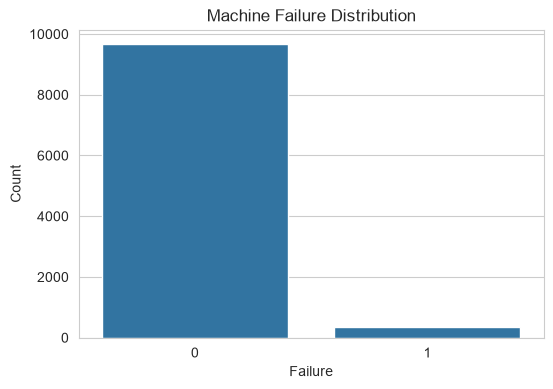

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Machine failure")

plt.title("Machine Failure Distribution")
plt.xlabel("Failure")
plt.ylabel("Count")

plt.show()

### Observation

Most machines are healthy, while only a small percentage experienced failures.

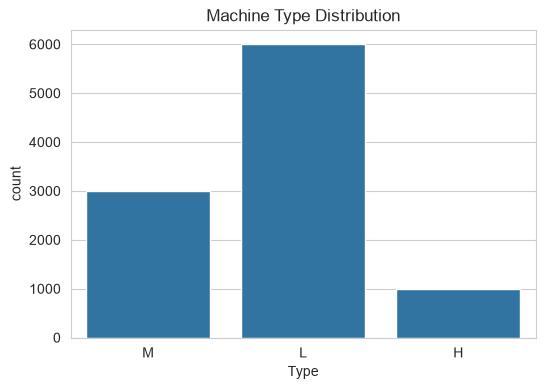

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Type")

plt.title("Machine Type Distribution")

plt.show()

Machine Type L has the highest number of samples.

In [13]:
print(df.columns.tolist())

['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


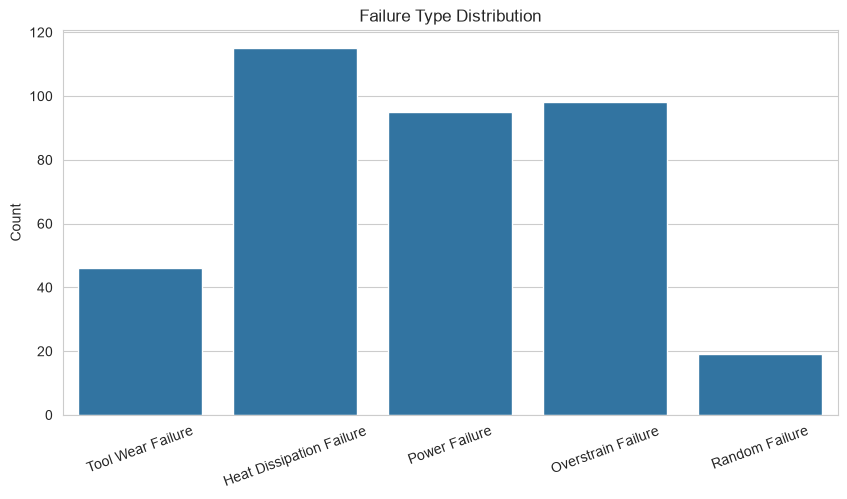

In [14]:
failure_counts = {
    "Tool Wear Failure": df["TWF"].sum(),
    "Heat Dissipation Failure": df["HDF"].sum(),
    "Power Failure": df["PWF"].sum(),
    "Overstrain Failure": df["OSF"].sum(),
    "Random Failure": df["RNF"].sum()
}

plt.figure(figsize=(10,5))

sns.barplot(
    x=list(failure_counts.keys()),
    y=list(failure_counts.values())
)

plt.xticks(rotation=20)
plt.title("Failure Type Distribution")
plt.ylabel("Count")

plt.show()

The majority of records belong to "No Failure", while actual failures are comparatively rare.

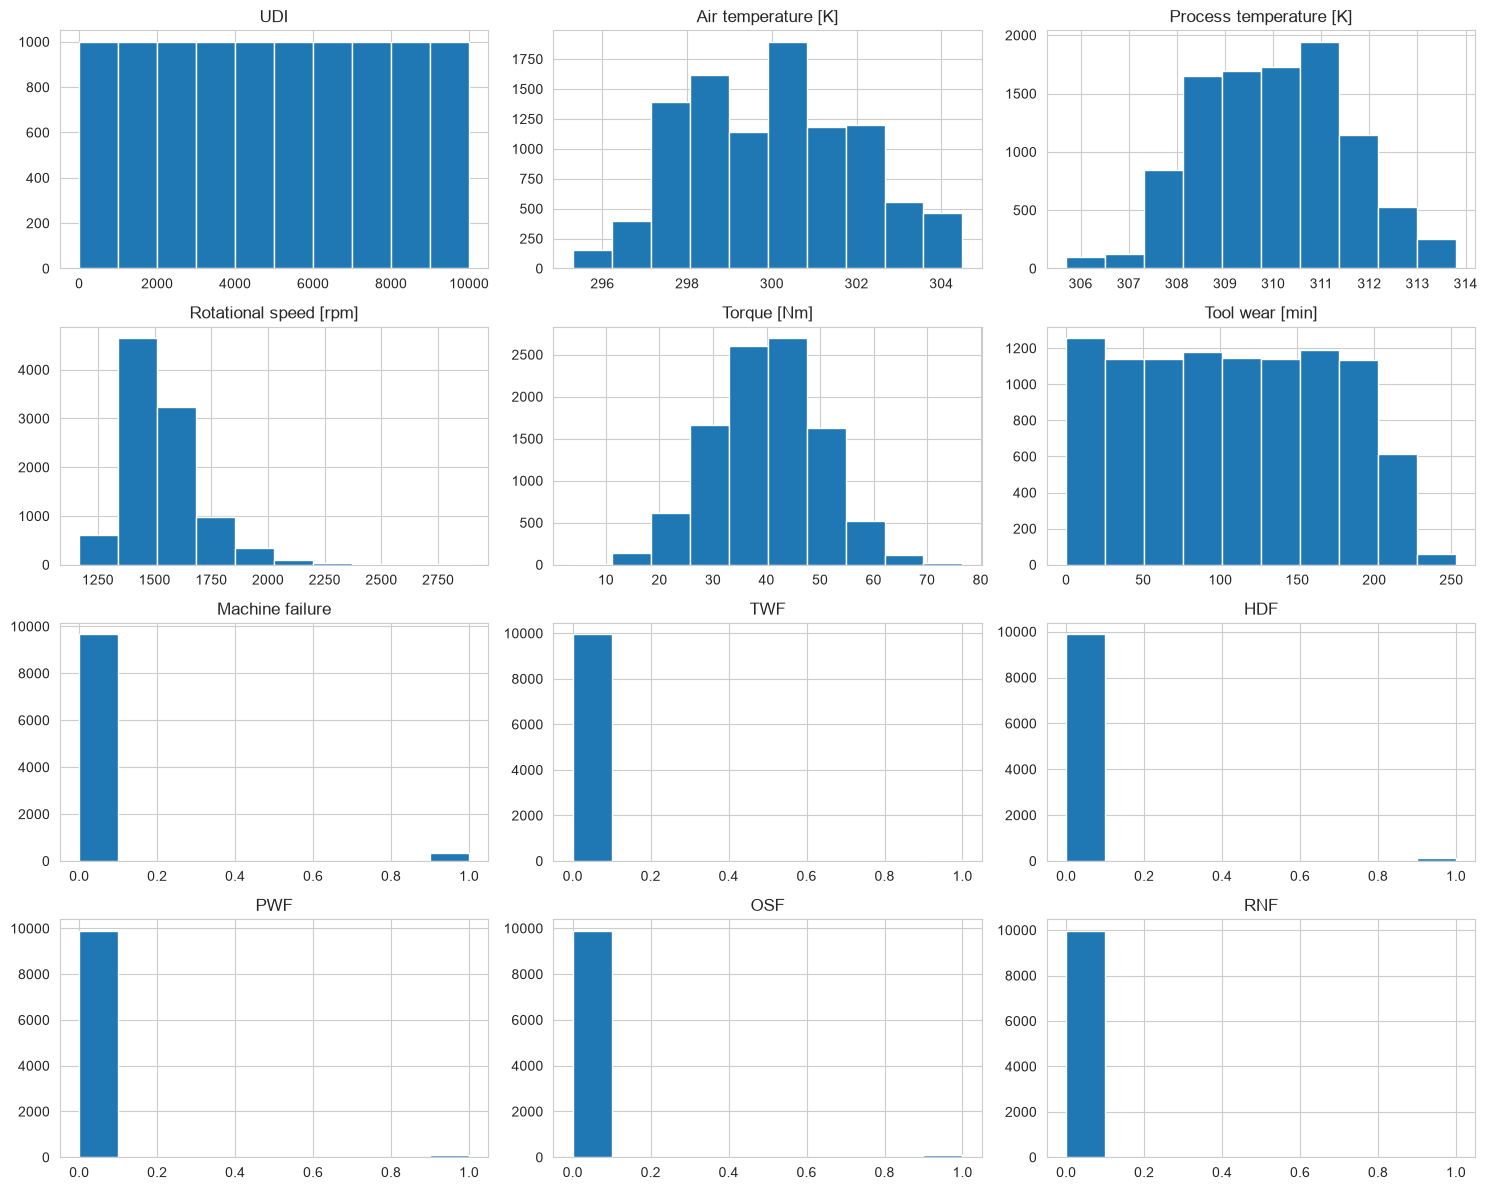

In [15]:
df.hist(figsize=(15,12))

plt.tight_layout()

plt.show()

The numerical features exhibit different distributions and ranges across sensor measurements.

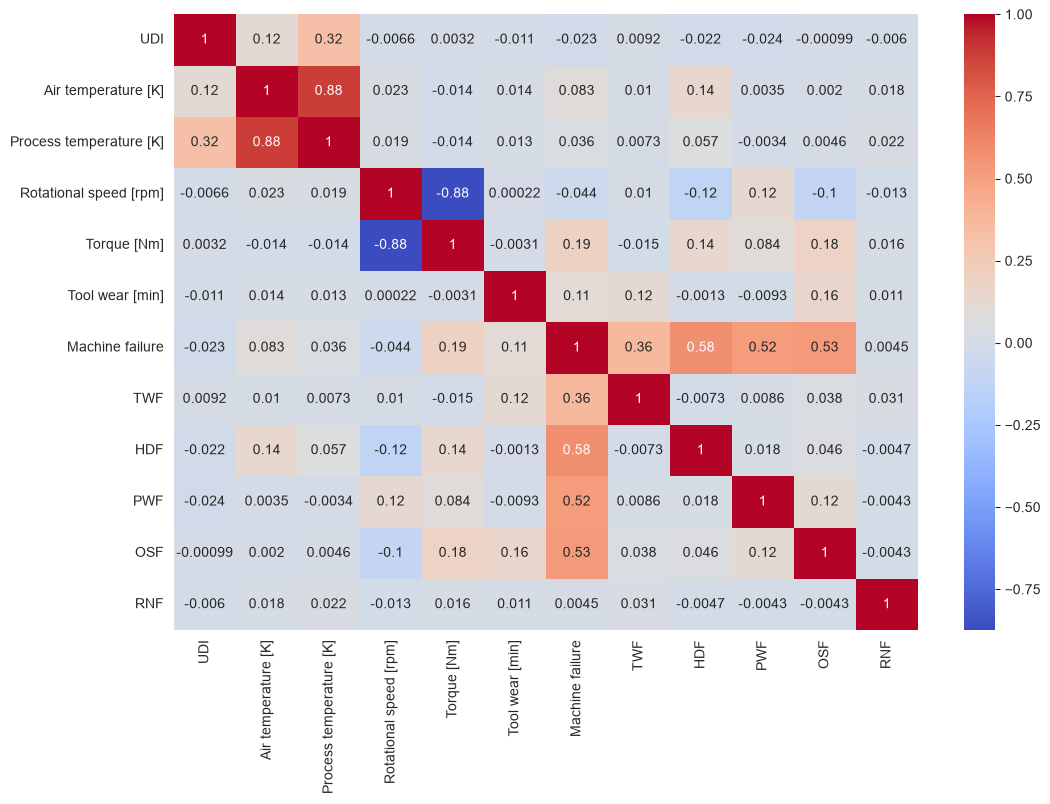

In [16]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.show()

Air Temperature and Process Temperature show a strong positive correlation.

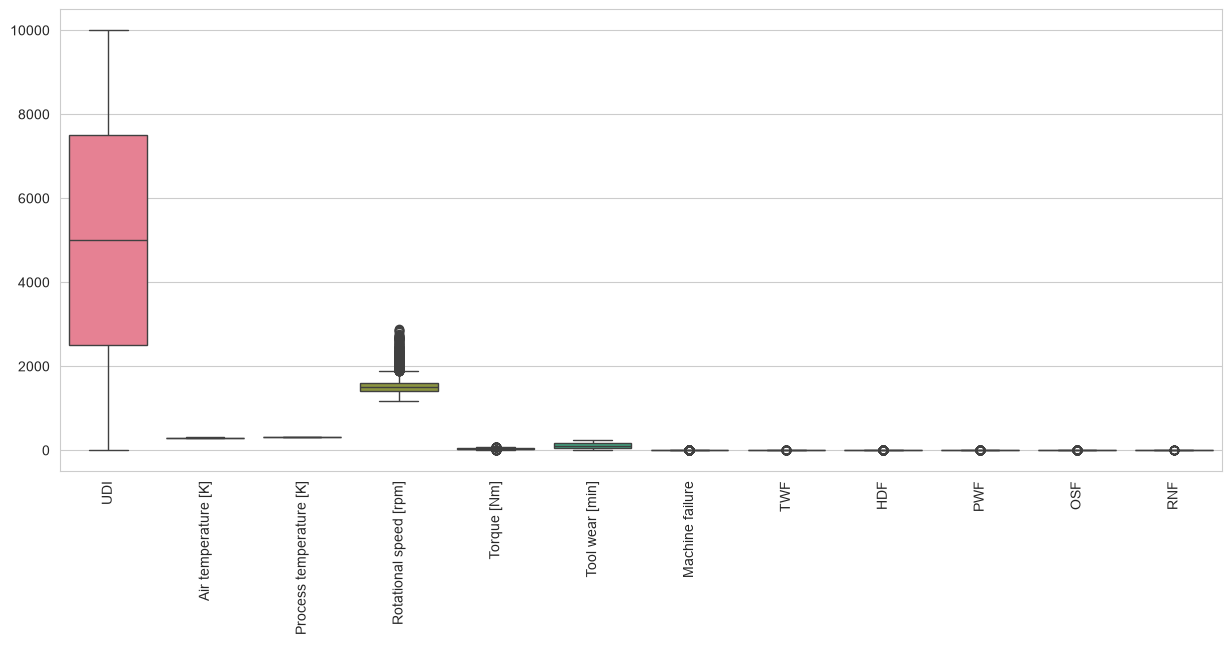

In [17]:
plt.figure(figsize=(15,6))

sns.boxplot(data=df.select_dtypes(include="number"))

plt.xticks(rotation=90)

plt.show()

Some numerical features contain outliers, particularly Tool Wear and Rotational Speed.

# Key Insights

1. The dataset contains no missing values.
2. The dataset is highly imbalanced.
3. Air Temperature and Process Temperature are strongly correlated.
4. Machine failures are relatively rare.
5. Some numerical features contain outliers.
6. The dataset is suitable for predictive maintenance.

# Conclusion

The exploratory data analysis shows that the AI4I 2020 dataset is clean, well-structured, and suitable for predictive maintenance. The analysis identified class imbalance, important feature relationships, and sensor distributions that will guide feature engineering and machine learning in the next phase.